<a href="https://colab.research.google.com/github/mlnjsh/timesage/blob/master/notebooks/timesage_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TimeSage Complete Demo - Airline Passengers Dataset

> **The Wise Time Series Library** - Beautiful EDA, All Models, Plain-English Interpretation

This notebook demonstrates **every feature** of timesage-ts using the classic airline passengers dataset.

- Install: `pip install timesage-ts[full]`
- Docs: [GitHub](https://github.com/mlnjsh/timesage)
- PyPI: [timesage-ts](https://pypi.org/project/timesage-ts/)

## Installation

In [35]:
!pip install timesage-ts[full] -q

## Import & Setup

In [36]:
import timesage as ts
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

ts.hello()

╭────────────────────────────────────────────── Welcome to TimeSage ──────────────────────────────────────────────╮
│ TimeSage v0.2.2                                                                                                 │
│ The Wise Time Series Library                                                                                    │
│                                                                                                                 │
│ Quick Start:                                                                                                    │
│   import timesage as ts                                                                                         │
│   data = ts.load_airline()                                                                                      │
│   series = ts.TimeSeries(data, target='passengers')                                                             │
│   series.eda()                                                                                                  │
│   result = series.forecast(horizon=30)                                                                          │
│   result.interpret()                                                                                            │
│                                                                                                                 │
│ Built-in Datasets: airline, sunspots, energy, synthetic_trend, synthetic_seasonal                               │
│ Models: ARIMA, ETS, Theta, RandomForest, XGBoost, LightGBM, Auto                                                │
│ Author: Milan Amrut Joshi                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Load Airline Passengers Dataset

Classic Box-Jenkins dataset: monthly totals of international airline passengers (1949-1960), 144 observations.

In [37]:
data = ts.load_airline()
print(f"Type: {type(data)}")
print(f"Shape: {data.shape}")
print(f"Date range: {data.index.min()} to {data.index.max()}")
data.head(10)

Type: <class 'pandas.core.frame.DataFrame'>
Shape: (144, 1)
Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00


,passengers
time,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


## Create TimeSeries Object

In [38]:
series = ts.TimeSeries(data, name="Airline Passengers")
print(series)

TimeSeries(name='Airline Passengers', length=144, freq='monthly', range=[1949-01-01 -> 1960-12-01])


## Basic Description

In [39]:
series.describe()

,passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000
skewness,0.583160
kurtosis,-0.364942


## Plot Raw Series

<Figure size 1200x500 with 0 Axes>

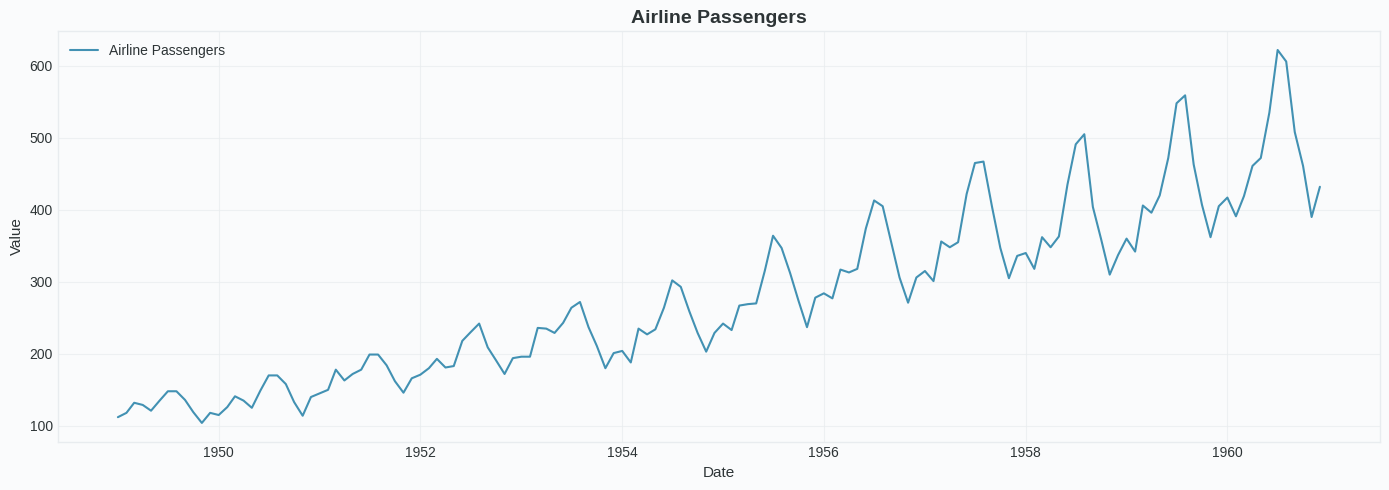

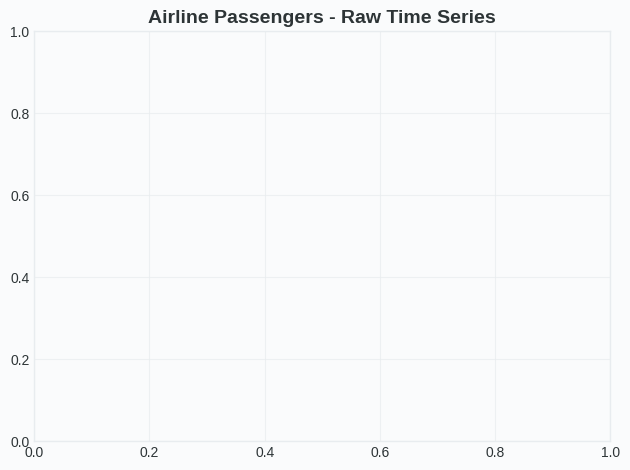

In [40]:
plt.figure(figsize=(12, 5))
series.plot()
plt.title("Airline Passengers - Raw Time Series", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Trend & Outlier Detection

<Figure size 1200x500 with 0 Axes>

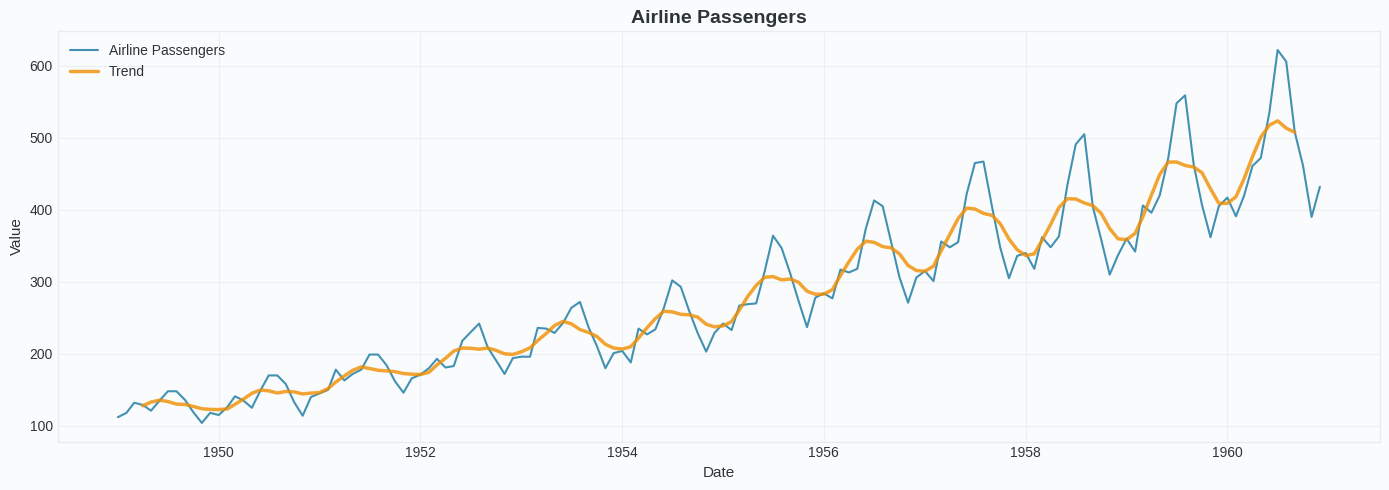

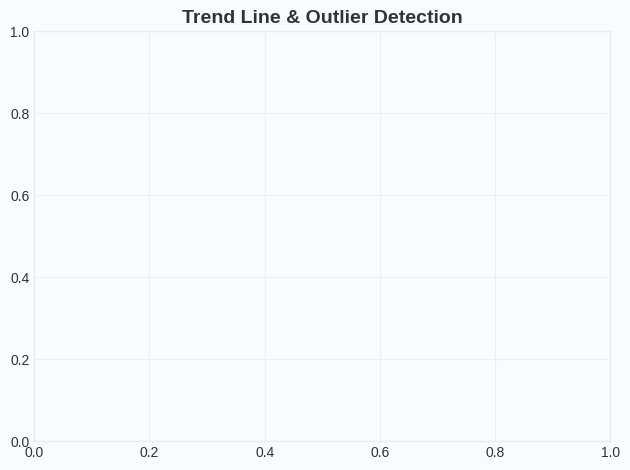

In [41]:
plt.figure(figsize=(12, 5))
series.plot(show_trend=True, show_outliers=True)
plt.title("Trend Line & Outlier Detection", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Theme Gallery

TimeSage ships with 3 themes: **sage** (default), **dark**, **minimal**.

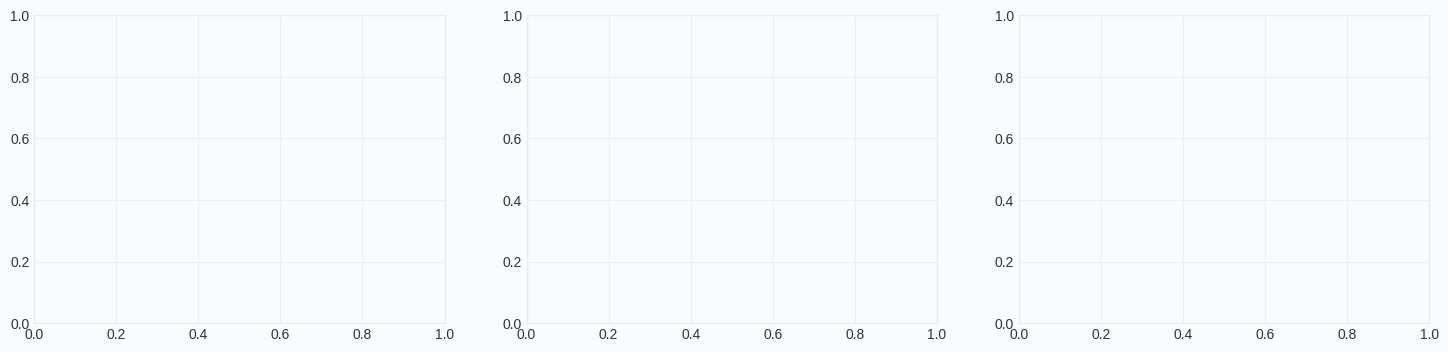

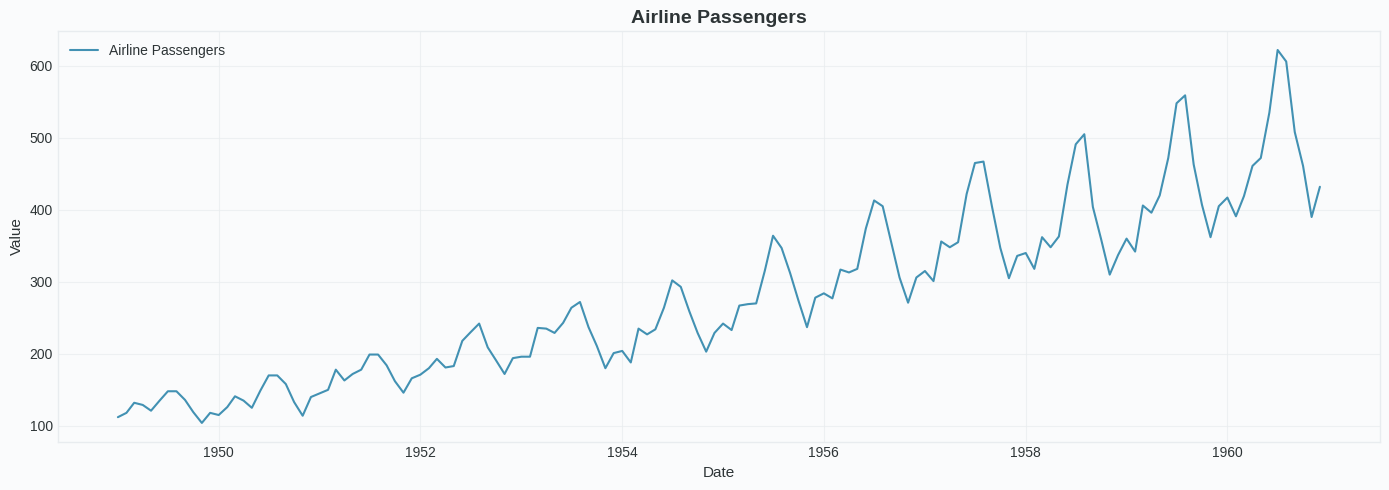

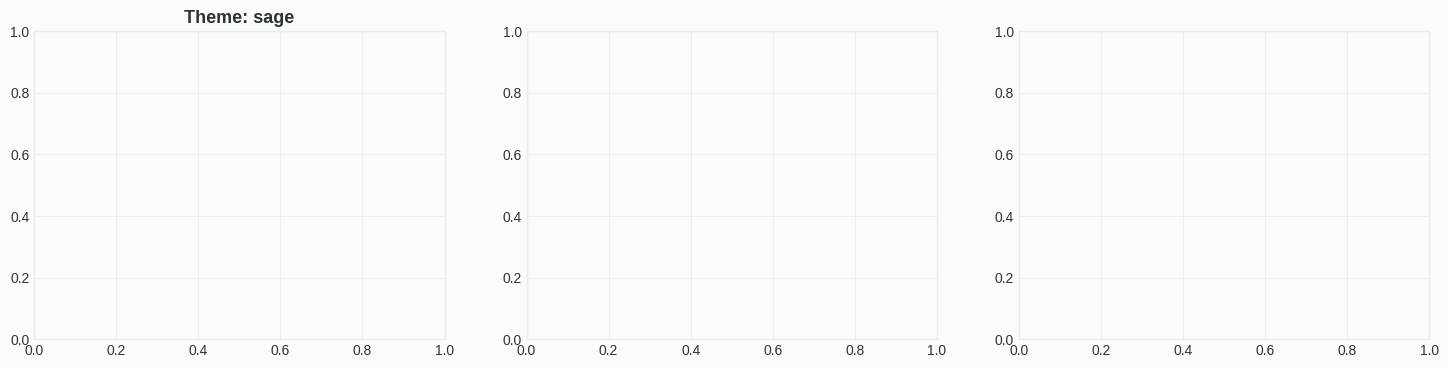

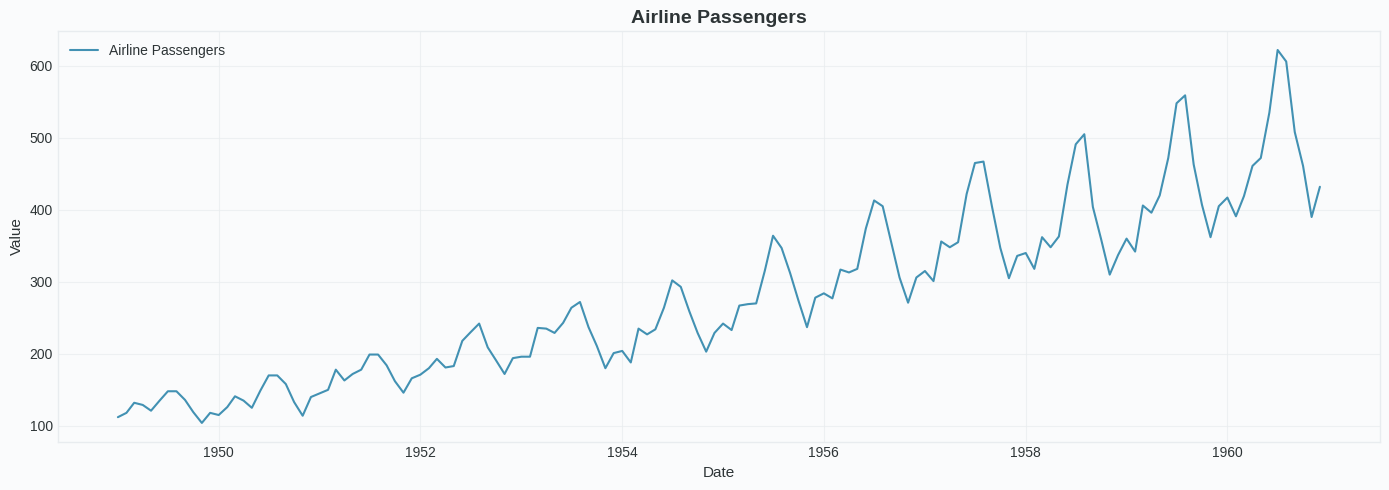

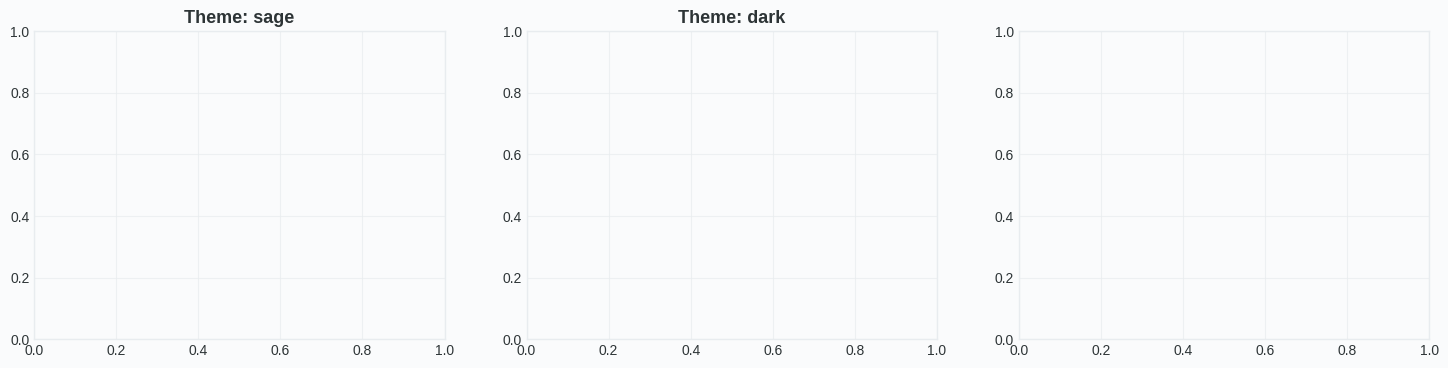

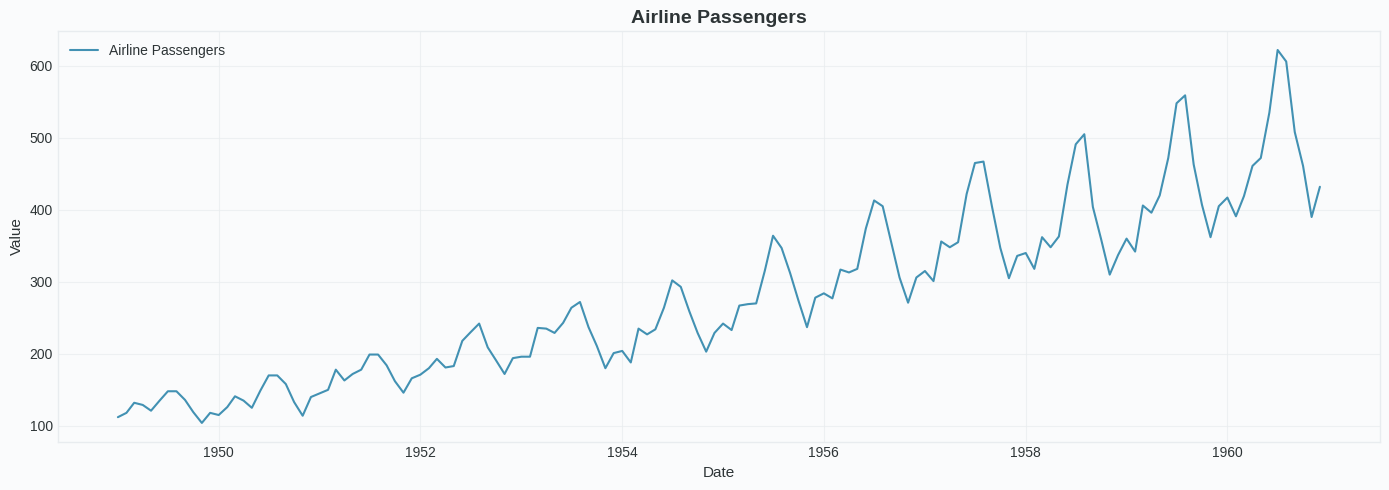

<Figure size 640x480 with 0 Axes>

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, theme_name in zip(axes, ["sage", "dark", "minimal"]):
    ts.set_theme(theme_name)
    plt.sca(ax)
    series.plot()
    ax.set_title(f"Theme: {theme_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
ts.set_theme("sage")

## Stationarity Testing

Augmented Dickey-Fuller (ADF) and KPSS tests.

In [43]:
series.test_stationarity()

                     Stationarity Tests                      
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Test                  ┃ Statistic ┃ P-value ┃ Stationary? ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━┩
│ ADF (H0: non-stat)    │    0.8154 │  0.9919 │     No      │
│ KPSS (H0: stationary) │    1.6513 │  0.0100 │     No      │
└───────────────────────┴───────────┴─────────┴─────────────┘

NON-STATIONARY -- Both tests agree the series has a unit root.

{'adf': {'statistic': np.float64(0.8153688792060498),
  'p_value': np.float64(0.991880243437641),
  'stationary': np.False_},
 'kpss': {'statistic': np.float64(1.6513122354165206),
  'p_value': np.float64(0.01),
  'stationary': np.False_},
 'conclusion': 'NON-STATIONARY -- Both tests agree the series has a unit root.'}

## Seasonality Detection

ACF peak analysis for seasonal patterns.

In [44]:
series.detect_seasonality()

Seasonality detected! Primary period: 12

{'seasonal': True,
 'period': 12,
 'peaks': [(12, np.float64(0.7603950422625557)),
  (24, np.float64(0.532189830465802)),
  (36, np.float64(0.33702359902053575))],
 'acf_values': array([1.        , 0.94804734, 0.87557484, 0.80668116, 0.75262542,
        0.71376997, 0.6817336 , 0.66290439, 0.65561048, 0.67094833,
        0.70271992, 0.74324019, 0.76039504, 0.71266087, 0.64634228,
        0.58592342, 0.53795519, 0.49974753, 0.46873401, 0.44987066,
        0.4416288 , 0.45722376, 0.48248203, 0.51712699, 0.53218983,
        0.49397569, 0.43772134, 0.3876029 , 0.34802503, 0.31498388,
        0.28849682, 0.27080187, 0.26429011, 0.27679934, 0.2985215 ,
        0.32558712, 0.3370236 , 0.30333486, 0.25397708, 0.21065534,
        0.17217092, 0.13840041, 0.11140324, 0.09098453, 0.08217177,
        0.08877222, 0.10386958, 0.12393082, 0.13263456])}

## ACF & PACF

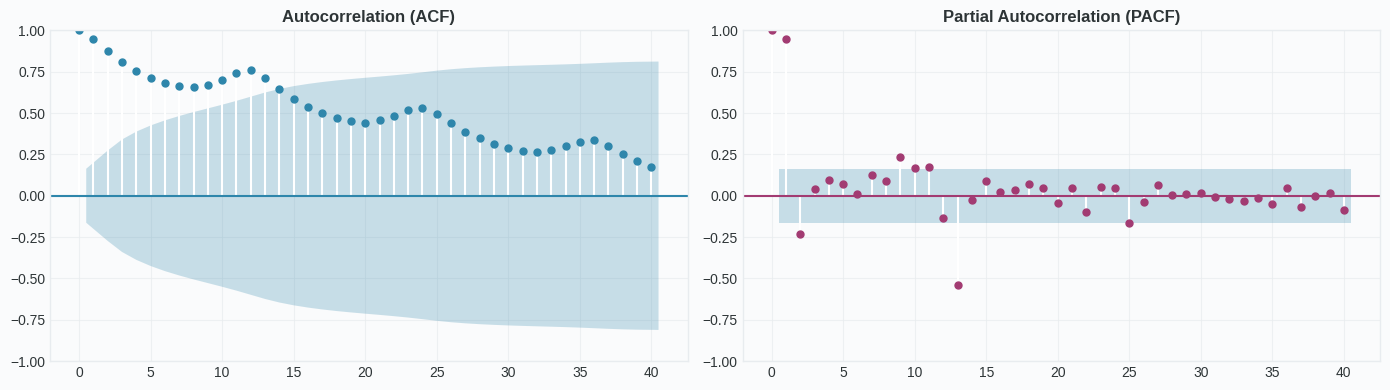

<Figure size 640x480 with 0 Axes>

In [45]:
series.plot_acf(lags=40)
plt.tight_layout()
plt.show()

## Time Series Decomposition

Trend + Seasonal + Residual components.

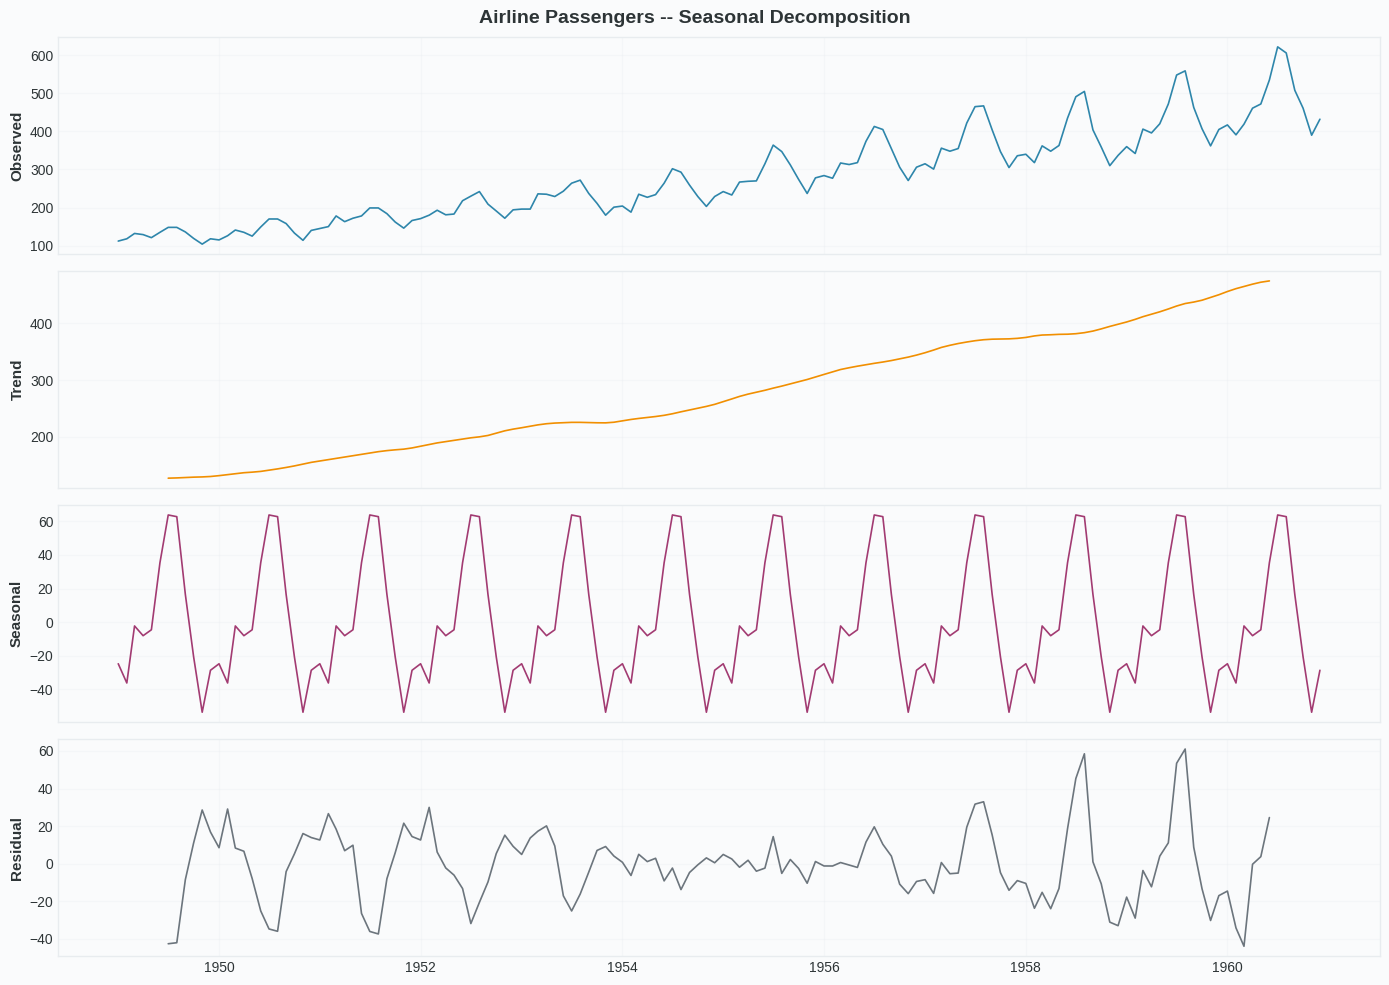

<Figure size 640x480 with 0 Axes>

In [46]:
series.decompose(model="additive", period=12)
series.plot_decomposition()
plt.tight_layout()
plt.show()

## Full EDA

One command for everything: description, stationarity, seasonality, and plots.

                     Stationarity Tests                      
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Test                  ┃ Statistic ┃ P-value ┃ Stationary? ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━┩
│ ADF (H0: non-stat)    │    0.8154 │  0.9919 │     No      │
│ KPSS (H0: stationary) │    1.6513 │  0.0100 │     No      │
└───────────────────────┴───────────┴─────────┴─────────────┘

NON-STATIONARY -- Both tests agree the series has a unit root.

Seasonality detected! Primary period: 12

    Summary Statistics    
┏━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric      ┃    Value ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ count       │ 144.0000 │
│ mean        │ 280.2986 │
│ std         │ 119.9663 │
│ min         │ 104.0000 │
│ 25%         │ 180.0000 │
│ 50%         │ 265.5000 │
│ 75%         │ 360.5000 │
│ max         │ 622.0000 │
│ skewness    │   0.5832 │
│ kurtosis    │  -0.3649 │
│ missing     │   0.0000 │
│ missing_pct │   0.0000 │
│ cv          │   0.4280 │
└─────────────┴──────────┘

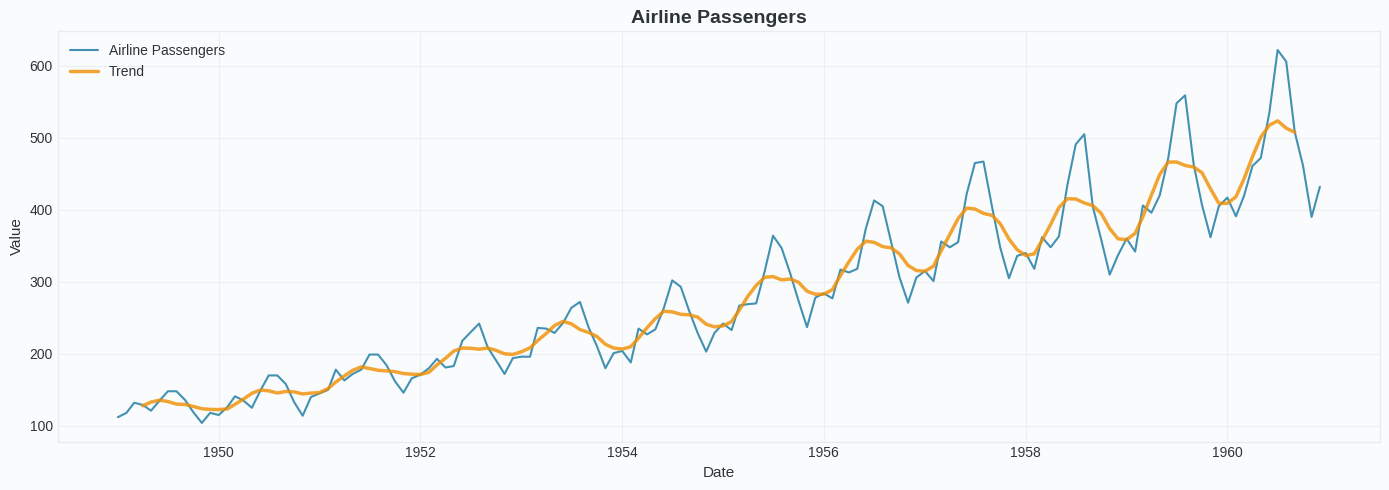

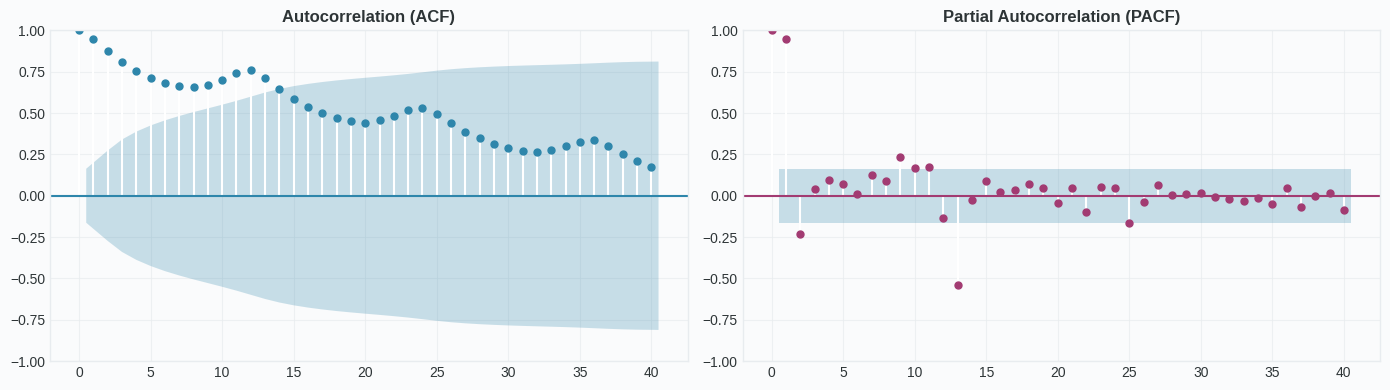

{'statistics': count          144.000000
 mean           280.298611
 std            119.966317
 min            104.000000
 25%            180.000000
 50%            265.500000
 75%            360.500000
 max            622.000000
 skewness         0.583160
 kurtosis        -0.364942
 missing          0.000000
 missing_pct      0.000000
 cv               0.427995
 Name: passengers, dtype: float64,
 'stationarity': {'adf': {'statistic': np.float64(0.8153688792060498),
   'p_value': np.float64(0.991880243437641),
   'stationary': np.False_},
  'kpss': {'statistic': np.float64(1.6513122354165206),
   'p_value': np.float64(0.01),
   'stationary': np.False_},
  'conclusion': 'NON-STATIONARY -- Both tests agree the series has a unit root.'},
 'seasonality': {'seasonal': True,
  'period': 12,
  'peaks': [(12, np.float64(0.7603950422625557)),
   (24, np.float64(0.532189830465802)),
   (36, np.float64(0.33702359902053575))],
  'acf_values': array([1.        , 0.94804734, 0.87557484, 0.80668116, 

In [47]:
series.eda(show_plots=True)

---
## Feature Engineering

Create ML features: lags, rolling stats, EWM, temporal features.

In [48]:
features_df = series.create_features(
    lags=[1, 2, 3, 6, 12, 24],
    windows=[3, 6, 12],
    temporal=True
)
print(f"Features shape: {features_df.shape}")
print(f"Columns: {list(features_df.columns)}")
features_df.head()

Features shape: (120, 34)
Columns: ['passengers', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'roll_mean_3', 'roll_std_3', 'roll_min_3', 'roll_max_3', 'roll_mean_6', 'roll_std_6', 'roll_min_6', 'roll_max_6', 'roll_mean_12', 'roll_std_12', 'roll_min_12', 'roll_max_12', 'ewm_7', 'ewm_14', 'ewm_30', 'diff_1', 'diff_7', 'pct_change_1', 'pct_change_7', 'day_of_week', 'day_of_month', 'month', 'quarter', 'week_of_year', 'is_weekend', 'is_month_start', 'is_month_end']


,passengers,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,roll_mean_3,roll_std_3,roll_min_3,...,pct_change_1,pct_change_7,day_of_week,day_of_month,month,quarter,week_of_year,is_weekend,is_month_start,is_month_end
time,,,,,,,,,,,,,,,,,,,,,
1951-01-01,145,140.0,114.0,133.0,170.0,115.0,112.0,133.000000,16.643317,114.0,...,0.035714,-0.026846,0,1,1,1,1,0,1,0
1951-02-01,150,145.0,140.0,114.0,170.0,126.0,118.0,145.000000,5.000000,140.0,...,0.034483,-0.117647,3,1,2,1,5,0,1,0
1951-03-01,178,150.0,145.0,140.0,158.0,141.0,132.0,157.666667,17.785762,145.0,...,0.186667,0.047059,3,1,3,1,9,0,1,0
1951-04-01,163,178.0,150.0,145.0,133.0,135.0,129.0,163.666667,14.011900,150.0,...,-0.084270,0.031646,6,1,4,2,13,1,1,0
1951-05-01,172,163.0,178.0,150.0,114.0,125.0,121.0,171.000000,7.549834,163.0,...,0.055215,0.293233,1,1,5,2,18,0,1,0


### Feature Pipeline Direct Use

In [49]:
from timesage.features import FeaturePipeline

pipeline = FeaturePipeline(target="passengers",
    lags=[1, 2, 3, 6, 12],
    windows=[3, 6, 12],
    temporal=True
)
feat_df = pipeline.transform(series.dataframe)
print(f"Total features: {feat_df.shape[1]}")
feat_df.dropna().head()

TypeError: FeaturePipeline.__init__() missing 1 required positional argument: 'target'

---
## Statistical Models

### ARIMA
Automatically selects best (p,d,q) via AIC grid search.

In [ ]:
result_arima = series.forecast(horizon=12, model="arima")
result_arima.summary()

In [ ]:
result_arima.plot()
plt.title("ARIMA Forecast", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### ETS (Holt-Winters)
Exponential smoothing with level, trend, and seasonality.

In [ ]:
result_ets = series.forecast(horizon=12, model="ets")
result_ets.summary()

In [ ]:
result_ets.plot()
plt.title("ETS Forecast", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Theta Method

In [ ]:
result_theta = series.forecast(horizon=12, model="theta")
result_theta.summary()

In [ ]:
result_theta.plot()
plt.title("Theta Forecast", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Machine Learning Models

### Random Forest

In [ ]:
result_rf = series.forecast(horizon=12, model="rf")
result_rf.summary()

In [ ]:
result_rf.plot()
plt.title("Random Forest Forecast", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### XGBoost

In [ ]:
result_xgb = series.forecast(horizon=12, model="xgboost")
result_xgb.summary()

In [ ]:
result_xgb.plot()
plt.title("XGBoost Forecast", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### LightGBM

In [ ]:
result_lgb = series.forecast(horizon=12, model="lightgbm")
result_lgb.summary()

In [ ]:
result_lgb.plot()
plt.title("LightGBM Forecast", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## AutoML - Automatic Model Selection

TimeSage trains ARIMA, ETS, Theta, RF on validation, picks the winner by lowest MAPE.

In [ ]:
result_auto = series.forecast(horizon=12, model="auto")
result_auto.summary()

In [ ]:
result_auto.plot()
plt.title("Auto Model Selection - Best Forecast", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Plain-English Interpretation

Understand your forecast without a statistics degree.

In [ ]:
result_auto.interpret()

### Detailed Interpretation Breakdown

In [ ]:
from timesage.interpret.explainer import explain_forecast

explanation = explain_forecast(result_auto)
for key, value in explanation.items():
    sep = "=" * 60
    print(f"
{sep}")
    print(f"  {key.upper().replace(chr(95), chr(32))}")
    print(f"{sep}")
    print(f"  {value}")

## Residual Diagnostics

Bias, normality, autocorrelation, heteroscedasticity checks.

In [ ]:
from timesage.interpret.diagnostics import diagnose_residuals

diagnosis = diagnose_residuals(result_auto.residuals)
for test_name, result in diagnosis.items():
    print(f"
{test_name}:")
    if isinstance(result, dict):
        for k, v in result.items():
            print(f"   {k}: {v}")
    else:
        print(f"   {result}")

## Model Comparison - All Models Side by Side

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
models = ["arima", "ets", "theta", "rf", "xgboost", "lightgbm"]
results = {}
for ax, model_name in zip(axes.flat, models):
    try:
        result = series.forecast(horizon=12, model=model_name)
        results[model_name] = result
        plt.sca(ax)
        result.plot()
        ax.set_title(f"{model_name.upper()} (MAPE: {result.mape:.1f}%)", fontsize=12, fontweight="bold")
    except Exception as e:
        ax.set_title(f"{model_name.upper()} - Error")
        ax.text(0.5, 0.5, str(e)[:80], ha="center", va="center", fontsize=9)
plt.suptitle("Model Comparison - Airline Passengers", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Metrics Comparison Table

In [ ]:
metrics_data = []
for name, res in results.items():
    metrics_data.append({
        "Model": name.upper(),
        "MAE": round(res.mae, 2),
        "RMSE": round(res.rmse, 2),
        "MAPE (%)": round(res.mape, 2),
        "R2": round(res.r2, 4),
        "MASE": round(res.mase, 4) if res.mase else None
    })
comparison_df = pd.DataFrame(metrics_data).sort_values("MAPE (%)")
print("Best model by MAPE:", comparison_df.iloc[0]["Model"])
comparison_df

## Custom Forecast Parameters

In [ ]:
result_custom = series.forecast(
    horizon=24,
    model="auto",
    test_size=0.2,
    confidence=0.95
)
result_custom.summary()

In [ ]:
result_custom.plot()
plt.title("Custom Forecast - 24 Months, 95% CI", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Feature Importance (ML Models)

In [ ]:
result_rf2 = series.forecast(horizon=12, model="rf")
if hasattr(result_rf2, "feature_importance") and result_rf2.feature_importance:
    print("Random Forest - Top Features:
")
    sorted_feats = sorted(result_rf2.feature_importance.items(), key=lambda x: x[1], reverse=True)
    for i, (name, score) in enumerate(sorted_feats[:15], 1):
        bar = chr(9608) * int(score * 50)
        print(f"  {i:2d}. {name:20s} {score:.4f} {bar}")
else:
    print("Feature importance not available")

## Other Built-in Datasets

In [ ]:
sunspots = ts.load_sunspots()
print(f"Sunspots: {sunspots.shape[0]} observations")
trend_data = ts.load_synthetic_trend()
seasonal_data = ts.load_synthetic_seasonal()
print(f"Synthetic Trend: {trend_data.shape[0]} observations")
print(f"Synthetic Seasonal: {seasonal_data.shape[0]} observations")

sun_series = ts.TimeSeries(sunspots, name="Sunspots")
plt.figure(figsize=(12, 4))
sun_series.plot()
plt.title("Sunspot Activity", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Color Palette

In [ ]:
from timesage.plot.theme import COLORS, PALETTE
print("TimeSage Color Palette:
")
for name, hex_code in COLORS.items():
    print(f"  {name:12s}  {hex_code}")
print(f"
Full palette: {PALETTE}")

---
## Summary

| Feature | Command |
|---|---|
| Load data | `ts.load_airline()` |
| TimeSeries | `ts.TimeSeries(data)` |
| Describe | `series.describe()` |
| Plot | `series.plot()` |
| Stationarity | `series.test_stationarity()` |
| Seasonality | `series.detect_seasonality()` |
| ACF/PACF | `series.plot_acf()` |
| Decompose | `series.decompose()` |
| Full EDA | `series.eda()` |
| Features | `series.create_features()` |
| ARIMA | `series.forecast(model="arima")` |
| ETS | `series.forecast(model="ets")` |
| Theta | `series.forecast(model="theta")` |
| Random Forest | `series.forecast(model="rf")` |
| XGBoost | `series.forecast(model="xgboost")` |
| LightGBM | `series.forecast(model="lightgbm")` |
| AutoML | `series.forecast(model="auto")` |
| Interpret | `result.interpret()` |
| Diagnostics | `diagnose_residuals()` |
| Themes | `ts.set_theme("dark")` |

---
**Made with [TimeSage](https://github.com/mlnjsh/timesage) | pip install timesage-ts[full]**